# Avance 2 — Regresión / Serie temporal del Dengue

**Idea (guía del profesor):** los datos crudos son registros individuales y **no tienen un
target numérico continuo**, por eso la regresión directa "no se puede". La solución es
**agregar a una serie temporal**: contar casos por semana y predecir el valor de la(s)
semana(s) siguiente(s) usando **ventanas de tiempo**.

**Selección de la ventana óptima:** similar al *método del codo* — se prueban varias ventanas
y se elige la mayor donde el error sigue siendo pequeño.

**Métricas:** R², RMSE, MAE.

## 0. Librerías

In [1]:
import sys; sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Agregación a serie temporal (casos por semana)

In [2]:
from data import cargar_crudo

df = cargar_crudo()
df['ano'] = pd.to_numeric(df['ano'], errors='coerce')
df['semana'] = pd.to_numeric(df['semana'], errors='coerce')
df = df.dropna(subset=['ano', 'semana'])
df = df[df['semana'].between(1, 53)]

serie = (df.groupby(['ano', 'semana']).size()
           .rename('casos').reset_index()
           .sort_values(['ano', 'semana']).reset_index(drop=True))
print('Puntos en la serie:', len(serie))
serie.head()

Puntos en la serie: 1305


,ano,semana,casos
0,2000,1,14
1,2000,2,28
2,2000,3,26
3,2000,4,27
4,2000,5,59


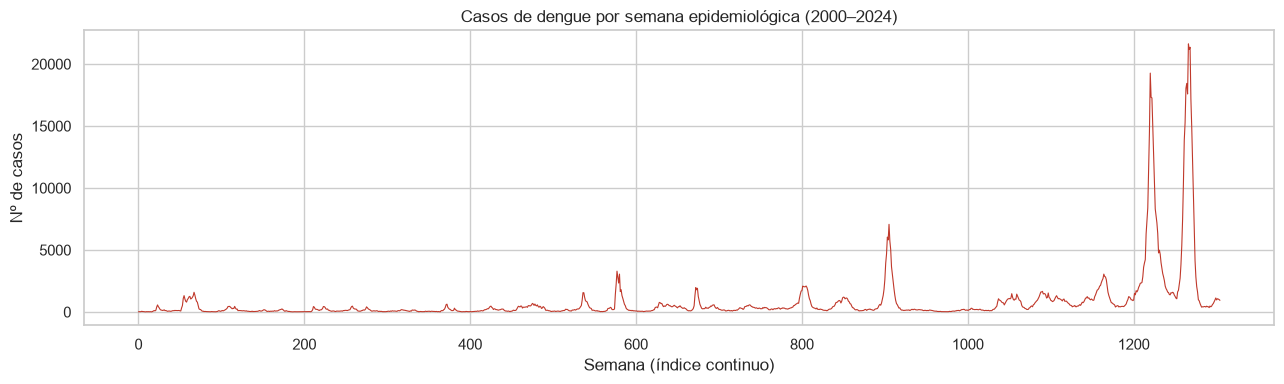

In [3]:
# Visualización de la serie completa
plt.figure(figsize=(13, 4))
plt.plot(serie['casos'].values, color='#c0392b', lw=0.8)
plt.title('Casos de dengue por semana epidemiológica (2000–2024)')
plt.xlabel('Semana (índice continuo)'); plt.ylabel('Nº de casos')
plt.tight_layout(); plt.show()

## 2. Construcción de ventanas de tiempo

Para una ventana `w`: usamos los `w` valores anteriores `[t-w, ..., t-1]` como features
para predecir el valor en `t`.

In [4]:
def crear_ventanas(valores, w):
    X, y = [], []
    for i in range(w, len(valores)):
        X.append(valores[i-w:i])
        y.append(valores[i])
    return np.array(X), np.array(y)

valores = serie['casos'].values.astype(float)

def evaluar(modelo, w, test_frac=0.2):
    X, y = crear_ventanas(valores, w)
    n_test = int(len(X) * test_frac)
    X_tr, X_te = X[:-n_test], X[-n_test:]
    y_tr, y_te = y[:-n_test], y[-n_test:]
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    return {
        'R2': r2_score(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'MAE': mean_absolute_error(y_te, pred),
    }, (y_te, pred)

## 3. Selección de la ventana óptima (método tipo codo)

            R2     RMSE      MAE
ventana                         
2        0.970  733.194  309.639
3        0.975  670.509  278.362
4        0.975  668.696  276.355
5        0.975  668.223  275.559
6        0.975  668.588  277.973
8        0.976  659.986  271.152
10       0.976  659.053  271.538
12       0.976  660.191  273.357


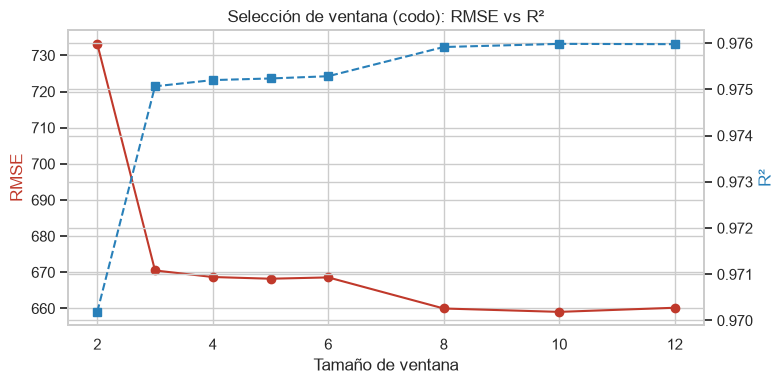

In [5]:
ventanas = [2, 3, 4, 5, 6, 8, 10, 12]
errores = []
for w in ventanas:
    m, _ = evaluar(Ridge(), w)
    errores.append({'ventana': w, **m})
err_df = pd.DataFrame(errores).set_index('ventana')
print(err_df.round(3))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(err_df.index, err_df['RMSE'], 'o-', color='#c0392b', label='RMSE')
ax1.set_xlabel('Tamaño de ventana'); ax1.set_ylabel('RMSE', color='#c0392b')
ax2 = ax1.twinx(); ax2.plot(err_df.index, err_df['R2'], 's--', color='#2980b9', label='R²')
ax2.set_ylabel('R²', color='#2980b9')
plt.title('Selección de ventana (codo): RMSE vs R²'); plt.tight_layout(); plt.show()

In [6]:
# Elegir la ventana con mejor R² (ajustar según el codo observado)
W = int(err_df['R2'].idxmax())
print('Ventana seleccionada:', W)

Ventana seleccionada: 10


## 4. Comparación de algoritmos de regresión

In [7]:
modelos = {
    'Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}
filas = {}
preds = {}
for nombre, modelo in modelos.items():
    m, (y_te, pred) = evaluar(modelo, W)
    filas[nombre] = m
    preds[nombre] = (y_te, pred)
tabla = pd.DataFrame(filas).T.round(3).sort_values('R2', ascending=False)
tabla

,R2,RMSE,MAE
Lineal,0.976,659.053,271.538
Ridge,0.976,659.053,271.538
Lasso,0.976,659.080,271.542
Random Forest,0.427,3220.193,1073.674
Gradient Boosting,0.353,3421.051,1153.846


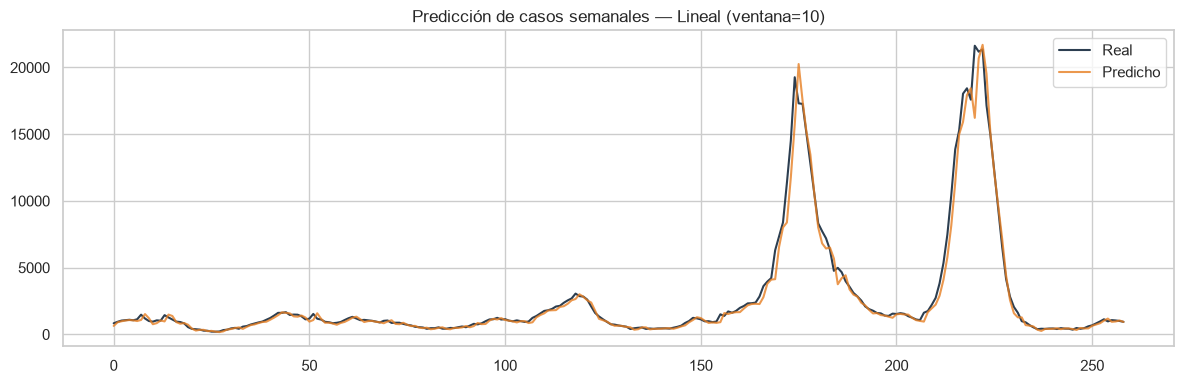

In [8]:
# Predicho vs Real del mejor modelo
mejor = tabla['R2'].idxmax()
y_te, pred = preds[mejor]
plt.figure(figsize=(12, 4))
plt.plot(y_te, label='Real', color='#2c3e50')
plt.plot(pred, label='Predicho', color='#e67e22', alpha=0.8)
plt.title(f'Predicción de casos semanales — {mejor} (ventana={W})')
plt.legend(); plt.tight_layout(); plt.show()

## 5. ¿Es adecuado el dataset para REGRESIÓN?

- Si tras agregar a serie semanal el **R²** es alto y el **RMSE** bajo → el dataset es adecuado
  para regresión / serie temporal (hay estructura temporal aprovechable).
- **Trabajo futuro:** comparar con **LSTM** (red recurrente), que es la técnica de referencia
  para series temporales, e incorporar variables exógenas (clima).

> Escribir aquí la conclusión observada.